In [93]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from scipy.signal import periodogram

path = '/home/mina-joojoo/Desktop/tool_wearing/'
dataset = pd.read_csv(path + 'correlated_dataset.csv')

In [94]:
dataset.columns

Index(['VB', 'machine_1.0', 'machine_2.0', 'machine_3.0', 'tool', 'C',
       'torque_x_mean', 'torque_x_max', 'torque_x_min', 'torque_x_rms',
       'torque_y_mean', 'torque_y_max', 'torque_y_min', 'torque_y_rms',
       'torque_z_std', 'torque_z_min', 'f_sens_mean', 'f_sens_max',
       'f_sens_min', 'f_sens_rms', 'fx_sens_mean', 'fx_sens_rms',
       'fx_sens_skew', 'fy_sens_mean', 'fy_sens_max', 'fy_sens_rms',
       'fz_sens_mean', 'fx_mean', 'fx_rms', 'fy_max', 'log_C'],
      dtype='object')

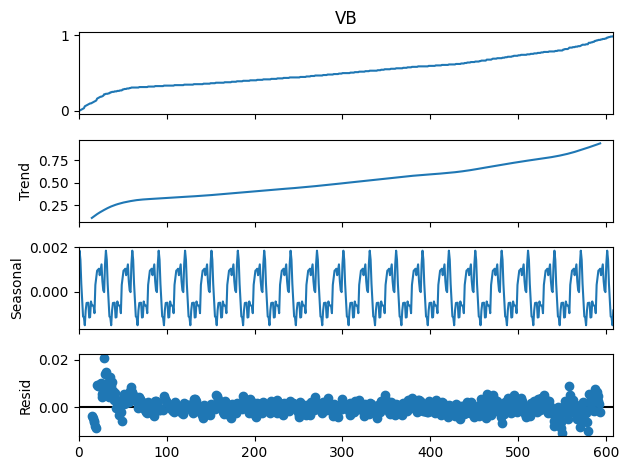

In [95]:
data = dataset[dataset['tool'] == 1]
result = seasonal_decompose(data['VB'], model='additive', period=30) 
fig = result.plot()

plt.show()

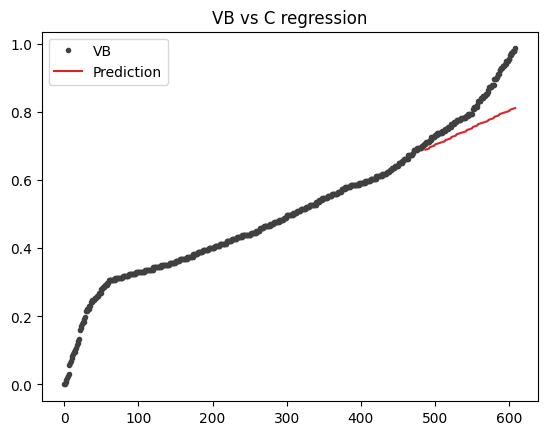

In [89]:
from sklearn.linear_model import LinearRegression

data = dataset[dataset['tool'] == 1]

l = int(0.8 * len(data['VB']))
train_y, test_y = data['VB'][:l], data['VB'][l:]
train_x, test_x = data['C'][:l], data['C'][l:]

train_x = train_x.values.reshape(-1, 1)
test_x = test_x.values.reshape(-1, 1)

model = LinearRegression()
model.fit(train_x, train_y)

y_pred = pd.Series(
    model.predict(test_x),
    index=test_y.index
)


ax = data['VB'].plot(color='0.25', style='.', title="VB vs C regression")
y_pred.plot(ax=ax, label="Prediction", color='C3')

ax.legend()

Text(0, 0.5, 'VB')

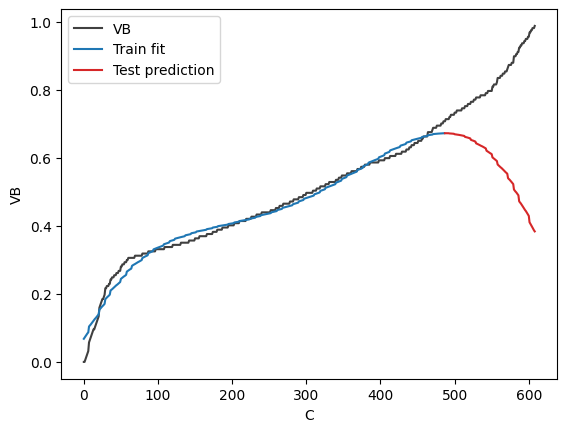

In [99]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

data = dataset[dataset['tool'] == 1]

l = int(0.8 * len(data['VB']))
train_y, test_y = data['VB'][:l], data['VB'][l:]
train_x, test_x = data['C'][:l], data['C'][l:]

train_x = train_x.values.reshape(-1, 1)
test_x = test_x.values.reshape(-1, 1)


poly = PolynomialFeatures(degree=4)
train_x_poly = poly.fit_transform(train_x)
test_x_poly = poly.transform(test_x)


model = LinearRegression()
model.fit(train_x_poly, train_y)


y_fit = pd.Series(
    model.predict(train_x_poly),
    index=train_y.index
)


y_pred = pd.Series(
    model.predict(test_x_poly),
    index=test_y.index
)


ax = data['VB'].plot(color='0.25')

y_fit.plot(ax=ax, label="Train fit", color='C0')
y_pred.plot(ax=ax, label="Test prediction", color='C3')

ax.legend()
ax.set_xlabel('C')
ax.set_ylabel('VB')


Add moving avg and legging